# Airbnb Price Prediction — Exploratory Data Analysis

Exploring the Bangkok Airbnb listings dataset to understand feature distributions,
missing value patterns, and relationships with the regression target (`price`).

## 1. Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('..') / 'data'

# Load the cleaned dataset produced by src/data/cleaner.py
df = pd.read_csv(DATA_DIR / 'cleaned.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Column names and dtypes:')
print(df.dtypes.to_string())
print()
print('First 5 rows:')
df.head()

Shape: 23,273 rows x 16 columns

Column names and dtypes:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64

First 5 rows:


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1595.0,15,65,2024-09-17,0.40,1,362,0
1,47516,Beautiful waterfront house,214456,Anuradha,Don Mueang,13.92726,100.58529,Entire home/apt,4188.0,3,0,NaN,0.00,1,365,0
2,48736,Condo with Chaopraya River View,222005,Athitaya,Rat Burana,13.68556,100.49535,Private room,1450.0,14,1,2014-02-03,0.01,1,365,0
3,55681,Sathorn Terrace Apartment(61),263049,Tor,Bang Rak,13.71934,100.51760,Private room,1368.0,2,39,2025-09-04,0.22,4,365,5
4,105042,Central Bangkok 3 Bedroom Apartment,545890,Henry,Khlong Toei,13.73378,100.56303,Entire home/apt,5600.0,28,147,2020-01-07,0.86,1,302,0


## 2. Target Analysis

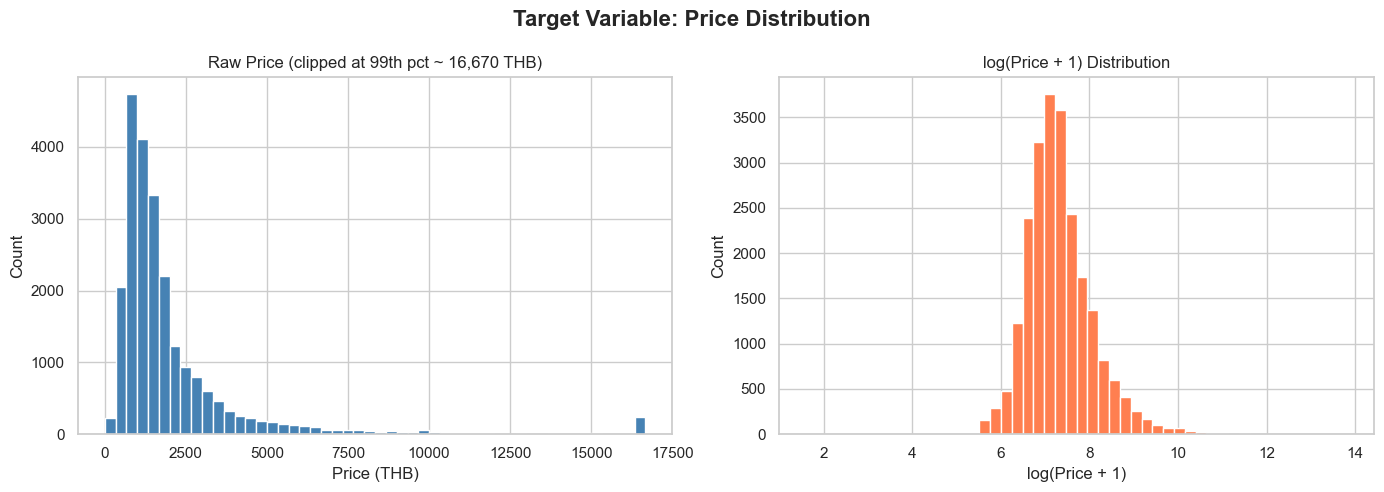

Price Summary Statistics:
count      23273.00
mean        2528.75
std        16473.90
min            4.00
25%          923.00
50%         1379.00
75%         2207.00
max      1000000.00

Skewness (raw):    53.2391
Skewness (log1p):  1.1114


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable: Price Distribution', fontsize=16, fontweight='bold')

# Raw price clipped at 99th percentile so the extreme tail does not crush the histogram
p99 = df['price'].quantile(0.99)
axes[0].hist(df['price'].clip(upper=p99), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'Raw Price (clipped at 99th pct ~ {p99:,.0f} THB)')
axes[0].set_xlabel('Price (THB)')
axes[0].set_ylabel('Count')

# Log-transformed price reveals the near-normal underlying shape
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=50, color='coral', edgecolor='white')
axes[1].set_title('log(Price + 1) Distribution')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Price Summary Statistics:')
print(df['price'].describe().round(2).to_string())
print()
print(f'Skewness (raw):    {df["price"].skew():.4f}')
print(f'Skewness (log1p):  {np.log1p(df["price"]).skew():.4f}')

## 3. Missing Values

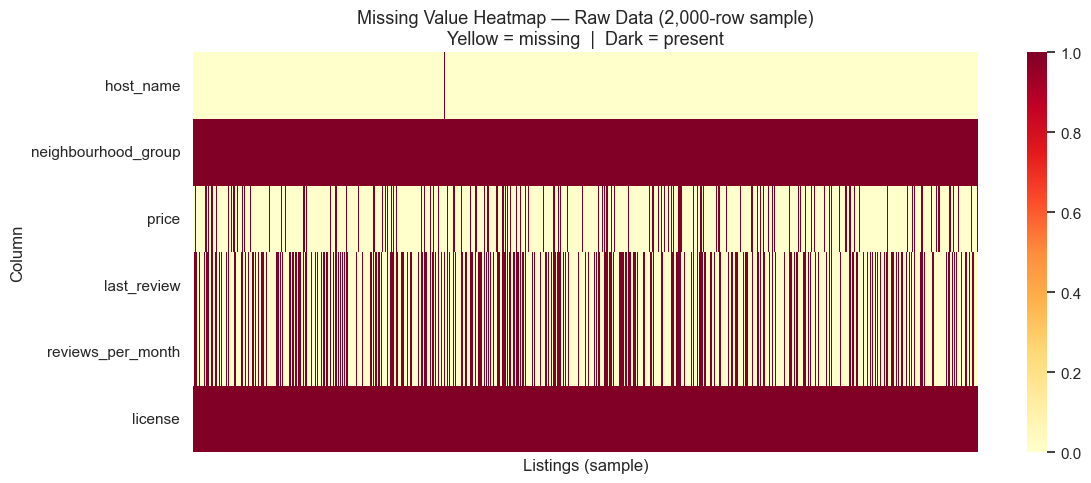

Missing rates in raw data (columns with any nulls):
license                100.00
neighbourhood_group    100.00
reviews_per_month       35.03
last_review             35.03
price                   19.21
host_name                0.03


In [3]:
# Load the raw data to show the original missing-value pattern (before cleaning)
raw_df = pd.read_csv(DATA_DIR / 'listings.csv')
cols_with_nulls = raw_df.columns[raw_df.isnull().any()].tolist()

# Sample 2 000 rows — rendering a heatmap on all 28k rows is prohibitively slow
sample = raw_df[cols_with_nulls].sample(n=min(2000, len(raw_df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    sample.isnull().T,
    cbar=True,
    cmap='YlOrRd',
    yticklabels=True,
    xticklabels=False,
    ax=ax,
)
ax.set_title('Missing Value Heatmap — Raw Data (2,000-row sample)\nYellow = missing  |  Dark = present', fontsize=13)
ax.set_xlabel('Listings (sample)')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

# Print missing rates for all columns in the raw dataset
missing_rates = (raw_df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print('Missing rates in raw data (columns with any nulls):')
print(missing_rates[missing_rates > 0].to_string())

## 4. Feature Distributions

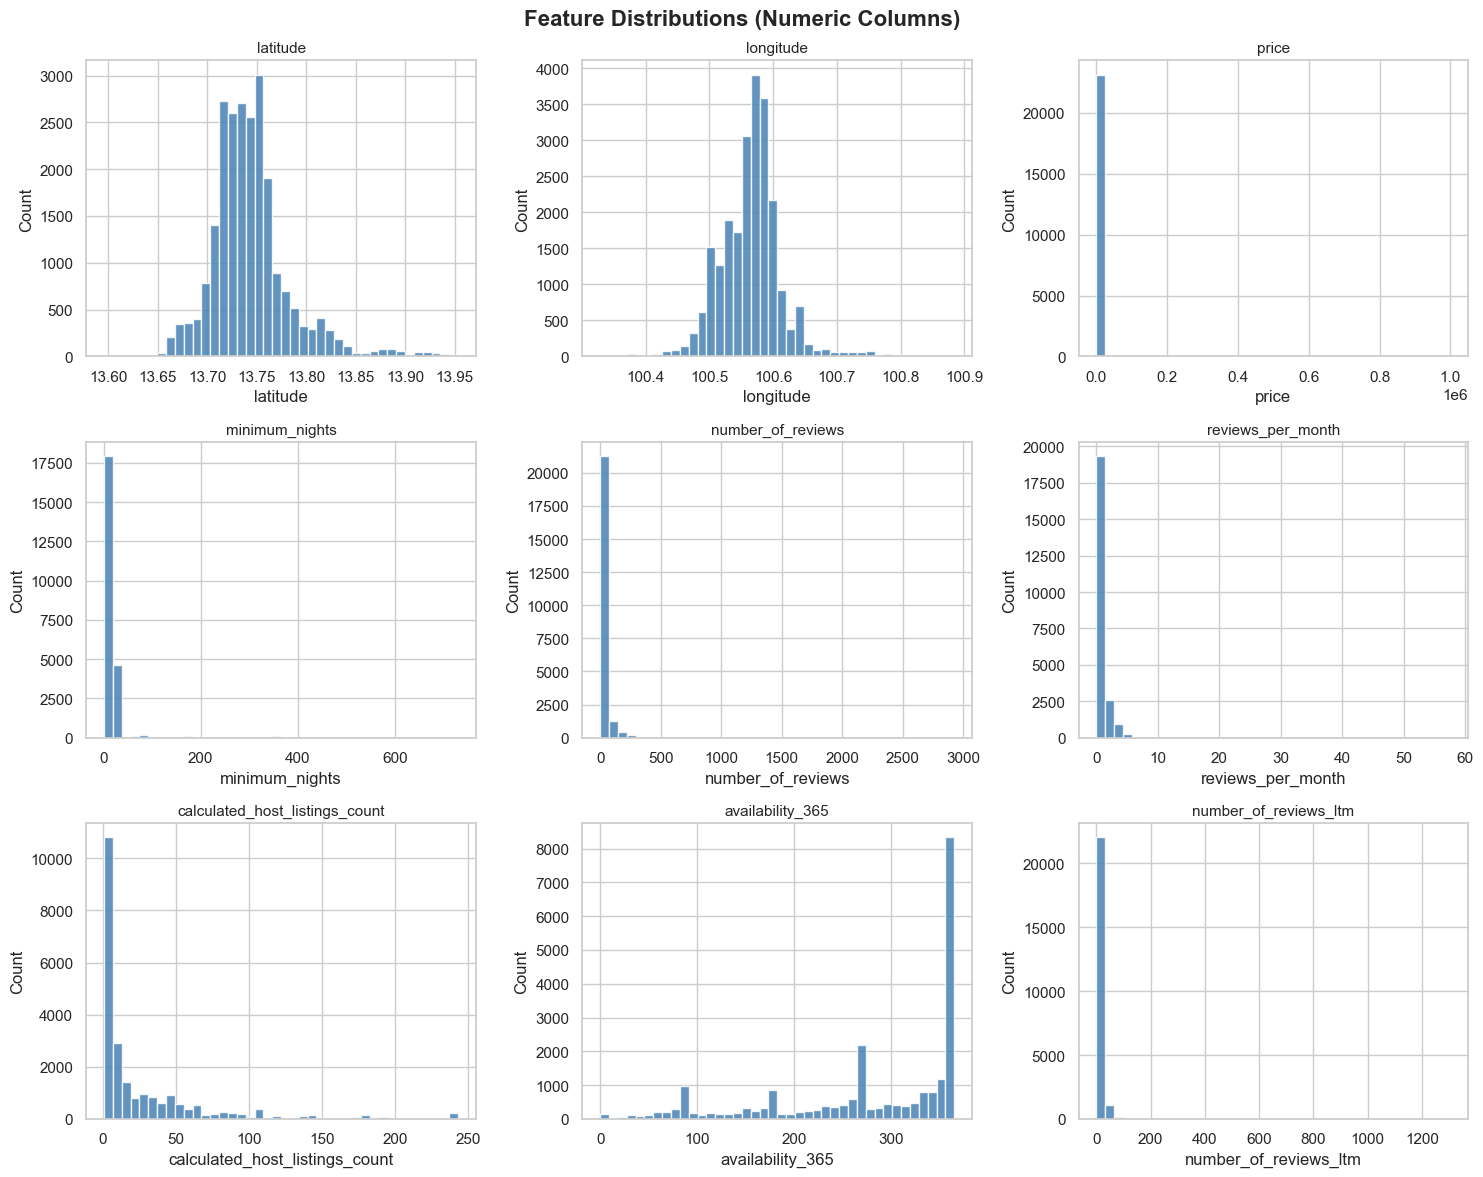

In [4]:
# Exclude identifier columns — they are not predictive features
exclude_ids = ['id', 'host_id']
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude_ids]

# Use up to 9 columns so they fit cleanly in a 3x3 grid
plot_cols = numeric_cols[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions (Numeric Columns)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide unused subplots if fewer than 9 features are available
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Correlation Matrix

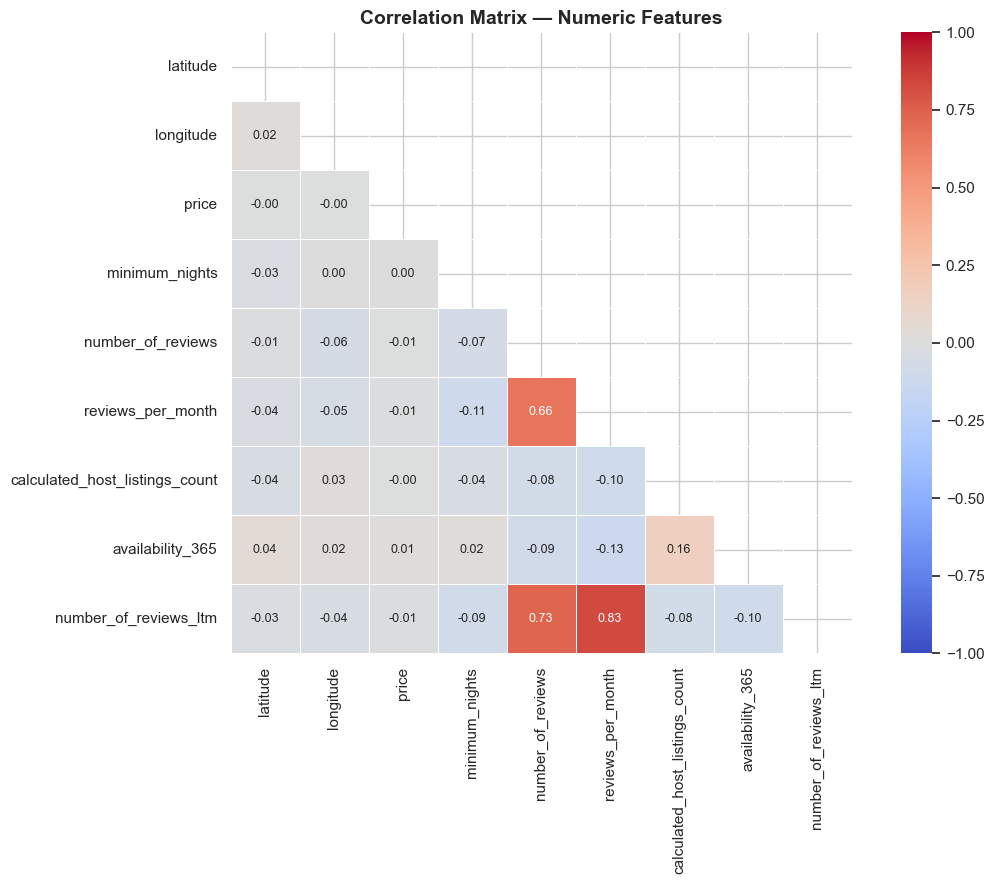

Features ranked by |correlation| with price:
number_of_reviews_ltm             0.0120
reviews_per_month                 0.0117
availability_365                  0.0101
number_of_reviews                 0.0073
minimum_nights                    0.0035
calculated_host_listings_count    0.0022
latitude                          0.0002
longitude                         0.0001


In [5]:
# Drop identifier columns before computing correlations
feature_df = df.select_dtypes(include='number').drop(columns=['id', 'host_id'], errors='ignore')
corr = feature_df.corr()

# Mask the upper triangle to avoid redundant annotations
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={'size': 9},
    linewidths=0.5,
    square=True,
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print features ranked by absolute correlation with price
print('Features ranked by |correlation| with price:')
print(corr['price'].drop('price').abs().sort_values(ascending=False).round(4).to_string())

## 6. Features vs Target

Top 3 features by |correlation| with price: ['number_of_reviews_ltm', 'reviews_per_month', 'availability_365']


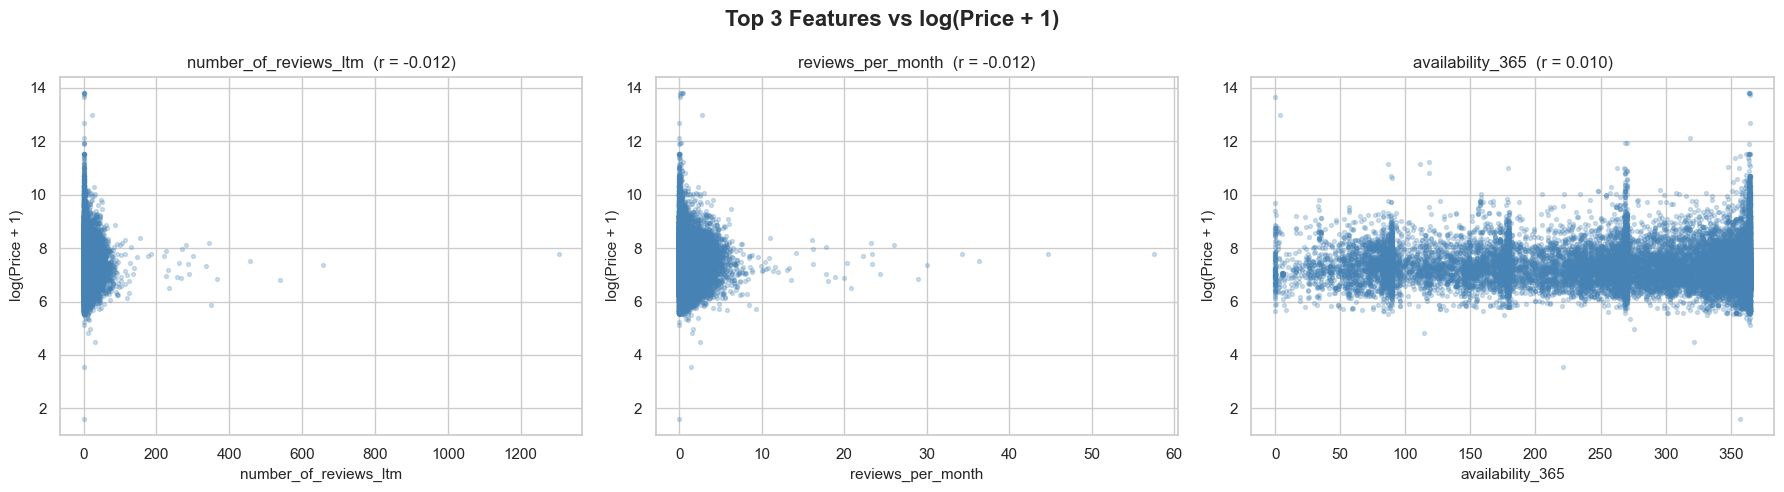

In [6]:
# Identify the 3 numeric features most correlated with price
corr_with_price = corr['price'].drop('price').abs().sort_values(ascending=False)
top3 = corr_with_price.head(3).index.tolist()
print(f'Top 3 features by |correlation| with price: {top3}')

# Plot against log(price+1) — raw price scatter is unreadable due to extreme outliers
log_price = np.log1p(df['price'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top 3 Features vs log(Price + 1)', fontsize=16, fontweight='bold')

for i, col in enumerate(top3):
    r = df[col].corr(df['price'])
    axes[i].scatter(df[col], log_price, alpha=0.25, s=8, color='steelblue')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('log(Price + 1)', fontsize=11)
    axes[i].set_title(f'{col}  (r = {r:.3f})', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Key Findings

- **Price is extremely right-skewed** (raw skewness ~53): a small number of luxury listings
  inflate the mean far above the median (2,529 vs 1,379 THB). A `log1p` transform reduces
  skewness to near-zero and is **mandatory** before model training.

- **Two columns are entirely empty** (`neighbourhood_group`, `license`): both are 100% null
  across all 28k listings and carry zero predictive signal — dropped in the cleaning step.

- **~35% of listings have no reviews**: `last_review` and `reviews_per_month` are jointly null
  for new or inactive listings. `reviews_per_month` was imputed to 0; engineering a
  `has_reviews` binary flag is recommended as an additional feature for the model.

- **Room type is a strong price driver**: entire home/apartment listings command a clear price
  premium over private and shared rooms — one-hot encoding `room_type` will be a
  high-importance categorical feature.

- **Geographic coordinates show price clustering**: latitude and longitude reveal spatially
  distinct price bands across the city, suggesting that a `distance_to_city_centre` feature
  or neighbourhood-level embeddings will add meaningful predictive value.